In [23]:
import os
import cv2
import numpy as np
import pandas as pd
import mediapipe as mp
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

In [24]:
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

In [25]:
def get_landmarks(frame):
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = face_mesh.process(rgb)
    if not results.multi_face_landmarks:
        return None
    lm = results.multi_face_landmarks[0]
    return np.array([(lm.landmark[i].x, lm.landmark[i].y, lm.landmark[i].z) 
                     for i in range(468)]).flatten()

W0000 00:00:1762011870.427452     505 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [26]:
SEQ_LEN = 30
FEATURES = 468 * 3

In [27]:
X, y = [], []
base = "/kaggle/input/uta-reallife-drowsiness-dataset"

W0000 00:00:1762011870.454326     506 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [28]:
# Map video name → label
label_map = {"0.mov": 0, "5.mov": 1, "10.mov": 2}  # Alert, Low-Vigilant, Drowsy

In [29]:
for root, dirs, files in os.walk(base):
    for file in files:
        if file in label_map:
            label = label_map[file]
            video_path = os.path.join(root, file)
            cap = cv2.VideoCapture(video_path)
            seq = []
            while len(seq) < SEQ_LEN:
                ret, frame = cap.read()
                if not ret:
                    break
                lm = get_landmarks(frame)
                if lm is not None:
                    seq.append(lm)
            cap.release()
            if len(seq) == SEQ_LEN:
                X.append(seq)
                y.append(label)

In [30]:
X = np.array(X)
y = to_categorical(y, 3)

print("Final dataset:", X.shape, y.shape)
print("Class distribution:", np.sum(y, axis=0))

Final dataset: (19, 30, 1404) (19, 3)
Class distribution: [7. 6. 6.]


In [31]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train:", X_train.shape, "Val:", X_val.shape)

Train: (15, 30, 1404) Val: (4, 30, 1404)


In [32]:
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(SEQ_LEN, FEATURES)),
    Dropout(0.3),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

In [33]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [34]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 128)        │       784,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 838,659 (3.20 MB)

 Trainable params: 838,659 (3.20 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
early = EarlyStopping(patience=7, restore_best_weights=True, monitor='val_accuracy')

In [36]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early],
    verbose=2
)

Epoch 1/100
1/1 - 3s - 3s/step - accuracy: 0.2000 - loss: 1.1260 - val_accuracy: 0.5000 - val_loss: 1.0828
Epoch 2/100
1/1 - 0s - 89ms/step - accuracy: 0.5333 - loss: 1.0757 - val_accuracy: 0.5000 - val_loss: 1.0825
Epoch 3/100
1/1 - 0s - 89ms/step - accuracy: 0.2667 - loss: 1.1184 - val_accuracy: 0.5000 - val_loss: 1.0858
Epoch 4/100
1/1 - 0s - 93ms/step - accuracy: 0.3333 - loss: 1.0849 - val_accuracy: 0.5000 - val_loss: 1.0947
Epoch 5/100
1/1 - 0s - 92ms/step - accuracy: 0.4000 - loss: 1.1253 - val_accuracy: 0.2500 - val_loss: 1.0989
Epoch 6/100
1/1 - 0s - 102ms/step - accuracy: 0.4000 - loss: 1.1274 - val_accuracy: 0.0000e+00 - val_loss: 1.1099
Epoch 7/100
1/1 - 0s - 92ms/step - accuracy: 0.3333 - loss: 1.0857 - val_accuracy: 0.0000e+00 - val_loss: 1.1134
Epoch 8/100
1/1 - 0s - 94ms/step - accuracy: 0.2667 - loss: 1.1093 - val_accuracy: 0.2500 - val_loss: 1.1115


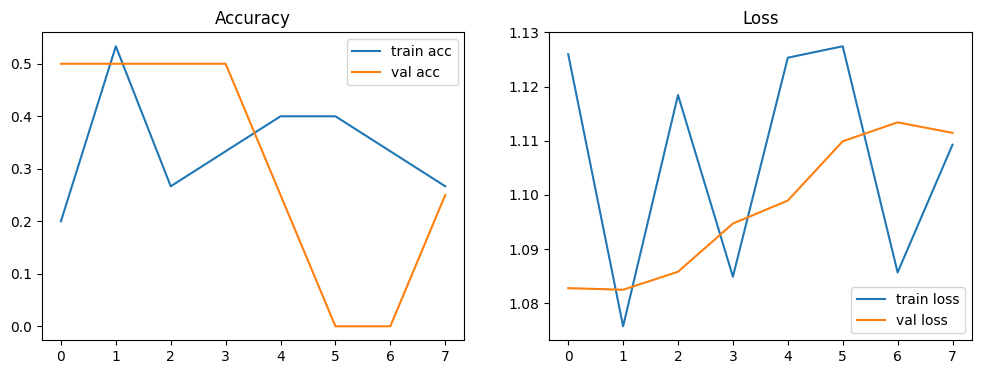

In [37]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend(); plt.title('Accuracy')
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend(); plt.title('Loss')
plt.show()

In [38]:
# Eye landmarks (MediaPipe IRIS)
LEFT_EYE  = [33, 133, 160, 159, 158, 144, 145, 153]
RIGHT_EYE = [362, 263, 387, 386, 385, 373, 374, 380]

In [39]:
def eye_aspect_ratio(landmarks):
    v1 = np.linalg.norm(landmarks[1] - landmarks[5])
    v2 = np.linalg.norm(landmarks[2] - landmarks[4])
    h  = np.linalg.norm(landmarks[0] - landmarks[3])
    return (v1 + v2) / (2 * h + 1e-6)

In [40]:
def live_alarm():
    cap = cv2.VideoCapture(0)
    closed_frames = 0
    THRESH = 0.20
    MAX_FRAMES = 60  # ~2 sec @ 30fps

    print("Press 'q' to quit")
    while True:
        ret, frame = cap.read()
        if not ret: break

        lm = get_landmarks(frame)
        if lm is not None:
            lm = lm.reshape(468, 3)
            ear = (eye_aspect_ratio(lm[LEFT_EYE]) + eye_aspect_ratio(lm[RIGHT_EYE])) / 2.0

            if ear < THRESH:
                closed_frames += 1
            else:
                closed_frames = 0

            if closed_frames > MAX_FRAMES:
                cv2.putText(frame, "ALARM: DROWSY!", (30, 100),
                            cv2.FONT_HERSHEY_SIMPLEX, 2, (0,0,255), 4)

            cv2.putText(frame, f"EAR: {ear:.3f}", (30, 50),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,0), 2)

        cv2.imshow("UTA-RLDD Drowsiness Detector", frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

print("Live alarm ready – uncomment to run")

Live alarm ready – uncomment to run


In [41]:
model.save("/kaggle/working/uta_rldd_lstm.h5")
print("Model saved → uta_rldd_lstm.h5")

Model saved → uta_rldd_lstm.h5
